In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/advertising-dataset/advertising.csv


# project overview
**This project analyzes TV Marketing (Advertising) data to understand how advertising spend across different channels impacts product Sales.

The project is treated as a real-world business problem, focusing not only on prediction accuracy but also on interpretability, insights, and decision-making support.**

# import libraries


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# load datasets # 

In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/advertising-dataset/advertising.csv')
df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


# EDA & visualization

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


**no missing values & datatype is float**

<Axes: >

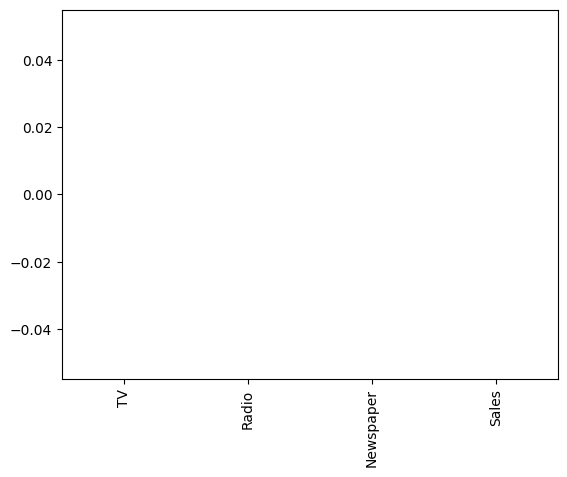

In [6]:
df.isna().sum().plot(kind='bar')

In [7]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

**there isnot any missing & null values**

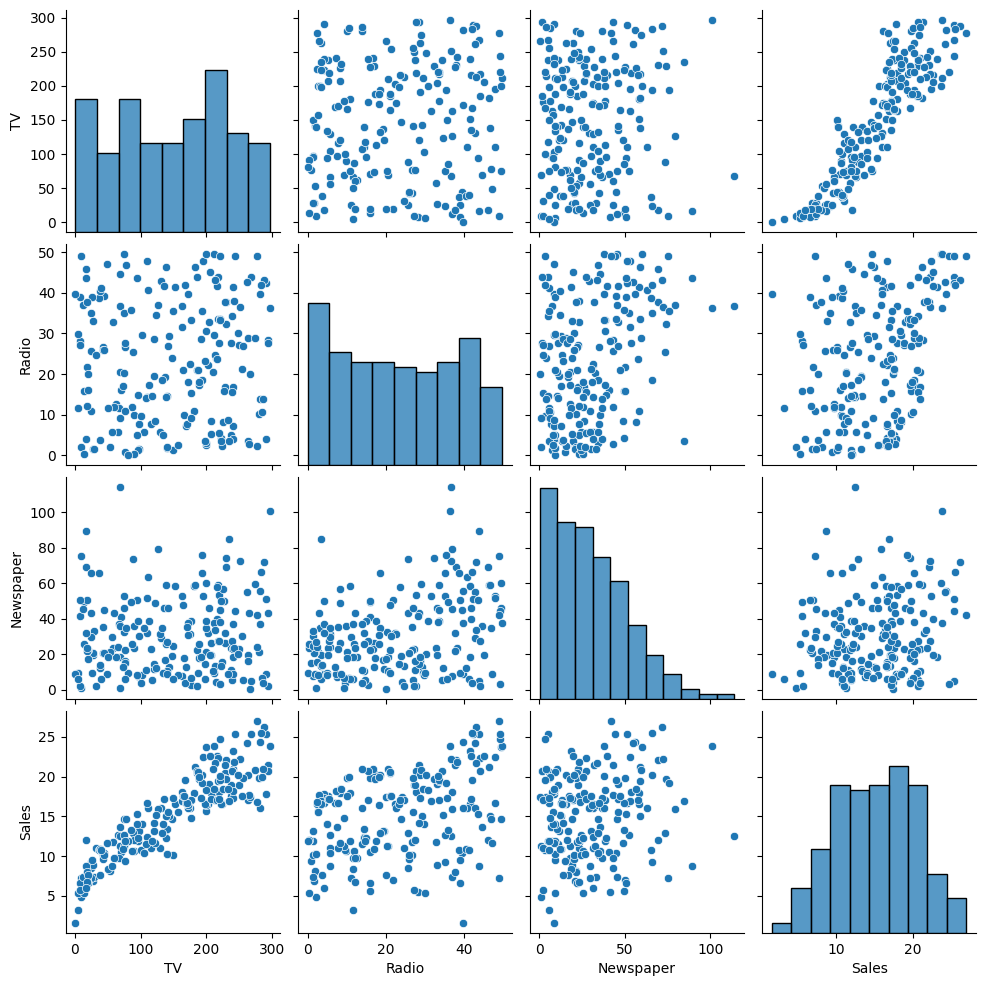

In [8]:
sns.pairplot(df)
plt.show()


<Axes: >

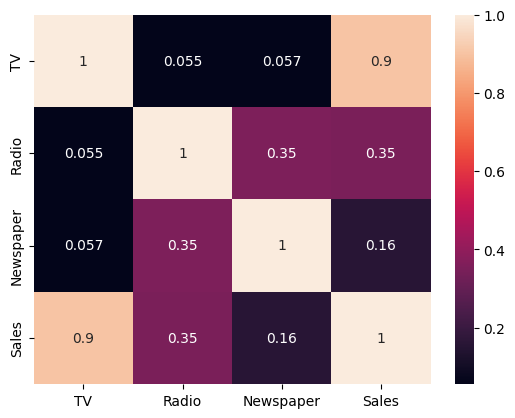

In [9]:
sns.heatmap(df.corr(),annot =True)

**we find that a tv has astrong relation with sales**

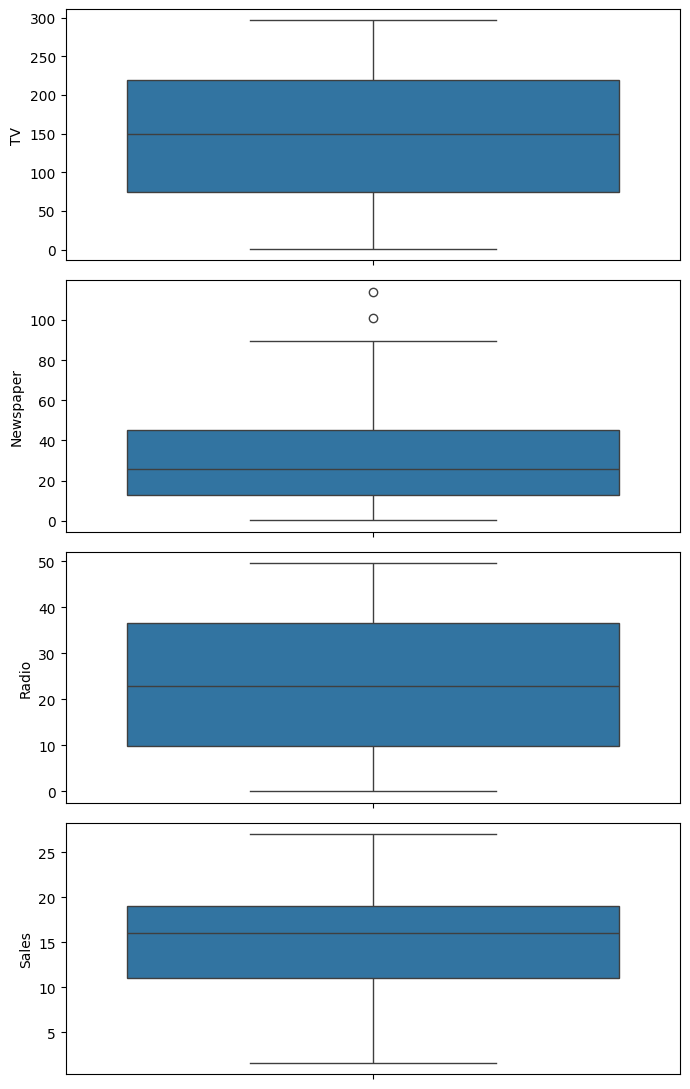

In [10]:
fig, axs = plt.subplots(4, figsize = (7,11))
plt1 = sns.boxplot(df['TV'], ax = axs[0])
plt2 = sns.boxplot(df['Newspaper'], ax = axs[1])
plt3 = sns.boxplot(df['Radio'], ax = axs[2])
plt3 = sns.boxplot(df['Sales'], ax = axs[3])


plt.tight_layout()

# Features and Target

In [11]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [12]:
print(X.shape)
print(y.shape)

(200, 3)
(200,)


# split data 

In [13]:
from sklearn.model_selection import train_test_split 
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
X_train.head()

,TV,Radio,Newspaper
79,116.0,7.7,23.1
197,177.0,9.3,6.4
38,43.1,26.7,35.1
24,62.3,12.6,18.3
122,224.0,2.4,15.6


In [15]:
y_train.head()

79     11.0
197    14.8
38     10.1
24      9.7
122    16.6
Name: Sales, dtype: float64

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


# try linear regression model 

In [17]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)


LinearRegression()

# Coefficients results

In [18]:
# Print the intercept and coefficients
print(lr.intercept_)
print(lr.coef_)

4.714126402214127
[0.05450927 0.10094536 0.00433665]


# prediction

In [19]:
y_pred = lr.predict(X_test)
y_pred

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

In [20]:
y_test

95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
115    12.6
69     22.3
170     8.4
174    16.5
45     16.1
66     11.0
182     8.7
165    16.9
78      5.3
186    10.3
177    16.7
56      5.5
152    16.6
82     11.3
68     18.9
124    19.7
16     12.5
148    10.9
93     22.2
65     11.3
60      8.1
84     21.7
67     13.4
125    10.6
132     5.7
9      15.6
18     11.3
55     23.7
75      8.7
150    16.1
104    20.7
135    11.6
137    20.8
164    11.9
76      6.9
Name: Sales, dtype: float64

# compare actual output vs predicted

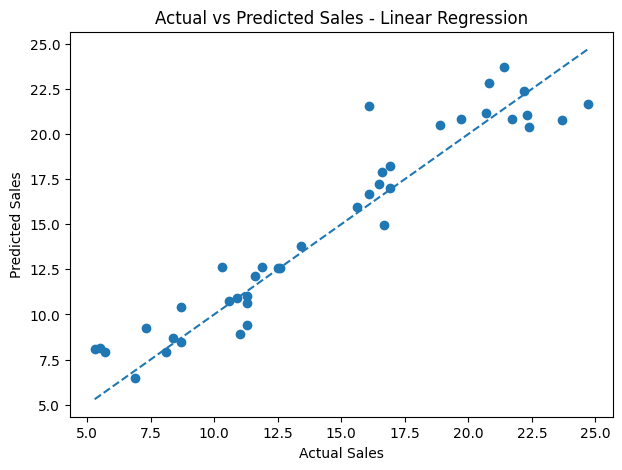

In [21]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Linear Regression")
plt.show()


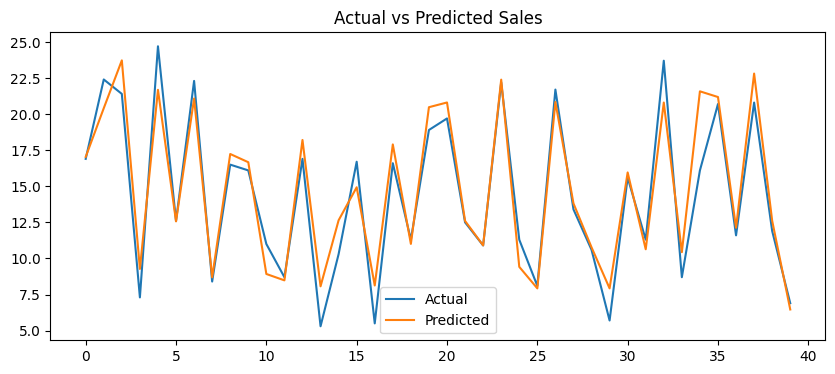

In [22]:
plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()


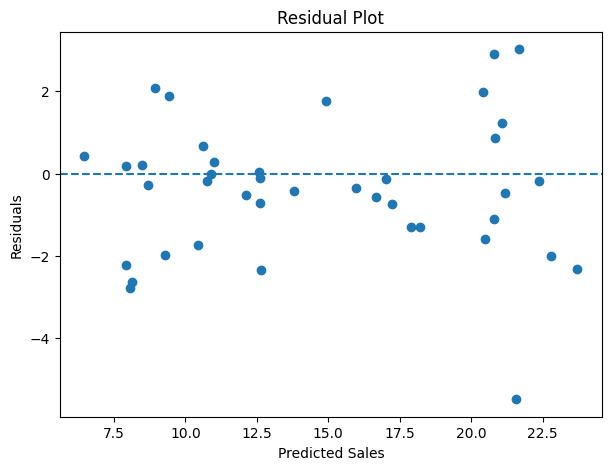

In [23]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


# evaluate the mode

In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [25]:
print("Linear Regression R2:", r2_score(y_test, y_pred))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred))


Linear Regression R2: 0.9059011844150826
Linear Regression MAE: 1.2748262109549338
Linear Regression MSE: 2.9077569102710896


Text(0, 0.5, 'Predicted Y')

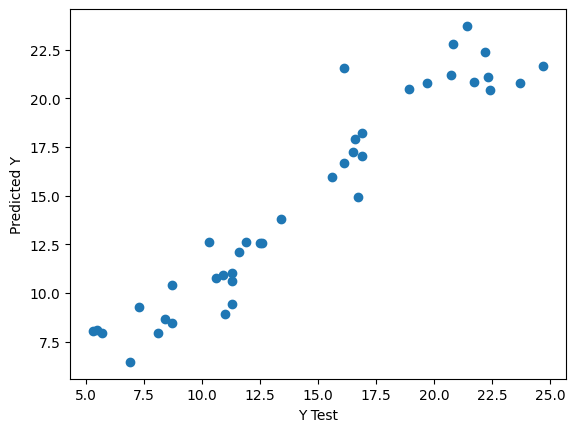

In [26]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

# using regularization to get best score (ridge & lasso)

In [27]:
from sklearn.linear_model import Ridge , Lasso

In [28]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
print("Lasso R2:", r2_score(y_test, y_pred_lasso))


Lasso R2: 0.9058967115743171


In [29]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
print("Ridge R2:", r2_score(y_test, y_pred_ridge))


Ridge R2: 0.9058999159458062


#  Coefficients compare 

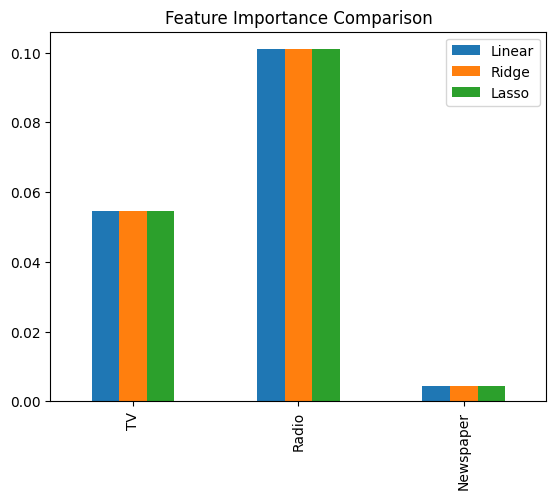

In [30]:
coef_df = pd.DataFrame({
    'Linear': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
}, index=X.columns)

coef_df.plot(kind='bar', title='Feature Importance Comparison')
plt.show()

# Hyperparameter Tuning ( choose best Alpha) & balance bias and variance 

In [31]:
from sklearn.model_selection import GridSearchCV

In [32]:
param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid_ridge = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    cv=5,
    scoring='r2'
)

grid_ridge.fit(X_train, y_train)

print("Best Ridge Alpha:", grid_ridge.best_params_)


Best Ridge Alpha: {'alpha': 100}


**BEST VALUE FOR ALPHA IN RIDGE IS 100 **

# USE GRIDSEARCHCV FOR FIND BEST VALUE FOR ALPHA IN LASSO & RIDGE

In [33]:
param_grid_lasso = {'alpha': [0.001, 0.01, 0.1, 1]}

grid_lasso = GridSearchCV(
    Lasso(max_iter=5000),
    param_grid_lasso,
    cv=5,
    scoring='r2'
)

grid_lasso.fit(X_train, y_train)

print("Best Lasso Alpha:", grid_lasso.best_params_)


Best Lasso Alpha: {'alpha': 0.1}


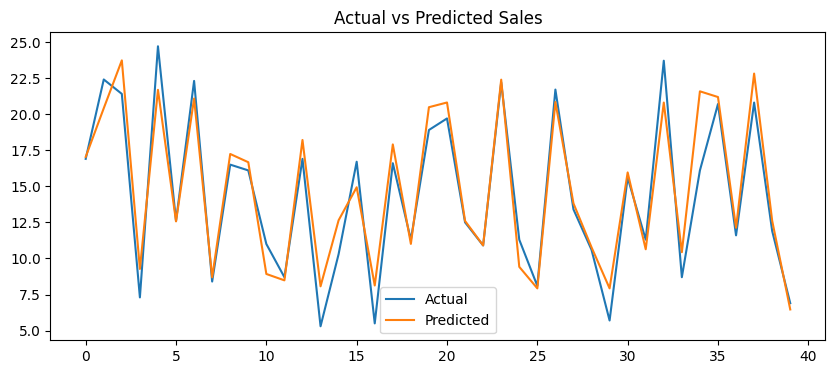

In [34]:
plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_lasso, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

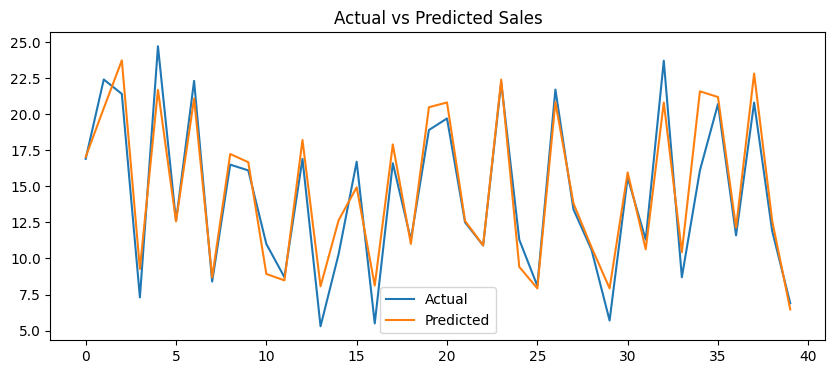

In [35]:
plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_ridge, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

**BEST VALUE FOR ALPHA IN LASSO IS 0.1**

In [36]:
from sklearn.preprocessing import PolynomialFeatures

In [37]:
from sklearn.pipeline import Pipeline

# use PolynomialFeatures

In [38]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

print("Polynomial Regression R2:", r2_score(y_test, y_pred_poly))


Polynomial Regression R2: 0.9533174341074886


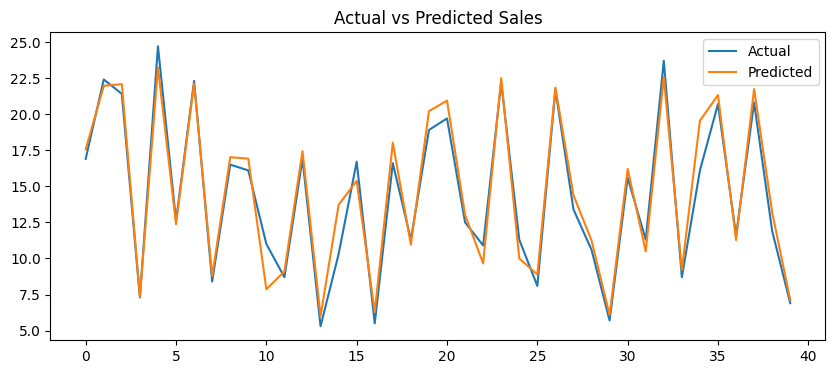

In [39]:
plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_poly, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

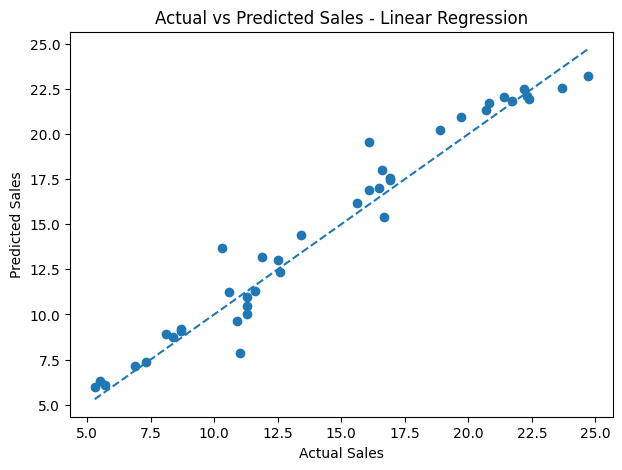

In [40]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_poly)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Linear Regression")
plt.show()


# final insights 

In [41]:
print("""
Final Insights:
- TV advertising has the strongest impact on Sales
- Ridge improves model stability
- Lasso highlights unimportant features
- Polynomial Regression slightly improves performance but reduces interpretability
""")



Final Insights:
- TV advertising has the strongest impact on Sales
- Ridge improves model stability
- Lasso highlights unimportant features
- Polynomial Regression slightly improves performance but reduces interpretability

